In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data = pd.read_parquet('../data/processed/model_features.parquet')
data.head(5)

,StockCode,Date,demand,revenue,average_price,transaction_count,day_of_week,month,day_of_month,week_of_year,...,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_std_7,rolling_max_7,price,average_price_7
0,10002,2010-02-23,48,40.80,0.85,2,1,2,23,8,...,24.0,3.0,3.0,12.0,13.428571,12.857143,10.453981,30.0,0.85,0.85
1,10002,2010-02-25,112,95.20,0.85,2,3,2,25,8,...,48.0,12.0,12.0,6.0,19.857143,16.071429,15.560940,48.0,0.85,0.85
2,10002,2010-02-28,1,0.85,0.85,1,6,2,28,8,...,112.0,1.0,18.0,73.0,34.142857,23.214286,37.534111,112.0,0.85,0.85
3,10002,2010-03-01,36,30.60,0.85,1,0,3,1,9,...,1.0,12.0,10.0,49.0,34.142857,22.000000,37.534111,112.0,0.85,0.85
4,10002,2010-03-03,200,144.00,0.72,1,2,3,3,9,...,36.0,30.0,12.0,2.0,37.571429,23.857143,36.248481,112.0,0.72,0.85


In [3]:
selected_product = data['StockCode'].value_counts().index[0]
product_data = data[data['StockCode'] == selected_product].sort_values('Date')
product_data['naive_weekly'] = (product_data['demand'].shift(7))
recent_data = product_data.tail(90)

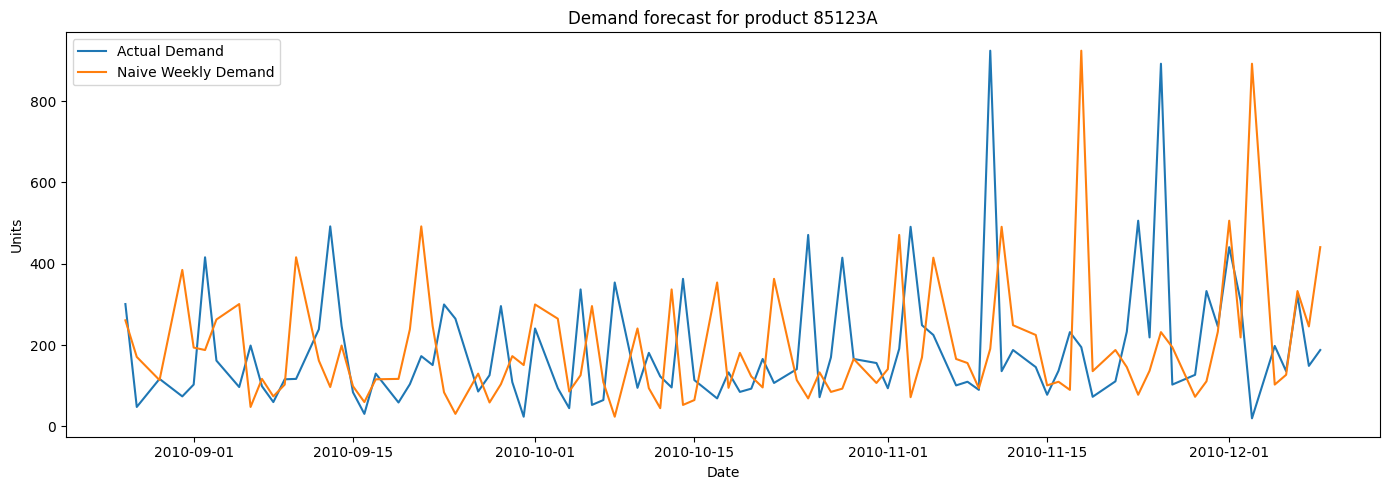

In [4]:
plt.figure(figsize=(14,5))

plt.plot(
    recent_data['Date'],
    recent_data['demand'],
    label='Actual Demand'
)

plt.plot(
    recent_data['Date'],
    recent_data['naive_weekly'],
    label='Naive Weekly Demand'
)

plt.title(f'Demand forecast for product {selected_product}')
plt.xlabel('Date')
plt.ylabel('Units')
plt.legend()
plt.tight_layout()
plt.show()